# ENGINEERING MATHEMATICS: DIFFERENTIAL EQUATIONS

- Homework 15%
- Midterm 42.5%
- Final Exam 42.5%

Every lecture is followed by 2 homework assignments.  
One is due Sunday 6am, the other is due Wednesday 6am.  
Previously, I say Saturday, no, it's Sunday.

Upload PDF to NTUCool.
Every minute of late submission will result in a penalty of 0.9999x.  
(Half-life is 4.8 days.)  
No excuse will be accepted.

Lecture Note (this notebook)
https://nm.lk/differ

Ask questions in DC
https://nm.lk/dc



## Course Schedule

| Week | Date | Topics |
|---|---|---|
| week1 | Sep 9 | Chap 1.1-1.2 |
| week2 | Sep 16 | Chap 1.3-2.1 |
| week3 | Sep 23 | Chap 2.2-2.3 |
| week4 | Sep 30 | Chap 2.4-2.5 |
| week5 | Oct 7 | Chap 2.5, 3.1, 3.2 |
| week6 | Oct 14 | Chap 4.1-4.2 |
| week7 | Oct 21 | Chap 4.3, 4.4, 4.5 |
| week8 | Oct 28 | Midterm Exam |
| week9 | Nov 4 | Chap 4.6, 4.7 |
| week10 | Nov 11 | Chap 6.1, 6.2 |
| week11 | Nov 18 | Chap 6.2, 6.3 |
| week12 | Nov 25 | Chap 11.1, 11.2 |
| week13 | Dec 2 | Chap 11.3, 12.1 |
| week14 | Dec 9 | Chap 12.4 |
| week15 | Dec 16 | Chap 12.4 + Applications of Differential Equations |
| week16 | Dec 23 | Final Exam |

## Motivation: From Discrete Updates to Differential Equations



### Example 1: a loan is naturally discrete, but...

Borrow **TWD 100,000 on the 1st** of the first month.  
Pay **TWD 1,000 on the 11th of each month**.  
On the **21st of each month**,  
interest of **0.5%** is added to the remaining balance.

| Date | Event | Balance (TWD) |
|---|---|---|
| Month 1, 1st | Borrow | 100,000.00 |
| Month 1, 11th | Repay 1,000 | 99,000.00 |
| Month 1, 21st | Add 0.5% interest | 99,495.00 |
| Month 2, 11th | Repay 1,000 | 98,495.00 |
| Month 2, 21st | Add 0.5% interest | 98,987.48 |
| Month 3, 11th | Repay 1,000 | 97,987.48 |
| Month 3, 21st | Add 0.5% interest | 98,477.41 |

Let the initial balance be $B_0 = 100{,}000$.
Let $B_n$ be the balance immediately after interest is added on the 21st of month $n$.  
Each cycle consists of **payment first, interest second**:
$$ B_n \longmapsto B_n - 1000 \longmapsto 1.005(B_n - 1000). $$

Thus, while the balance exceeds the scheduled payment,
$$ \boxed{B_{n + 1} = 1.005(B_n - 1000).} $$
The first two balances are
$$ B_1 = 99{,}495, \qquad B_2 = 98{,}987.475\quad\text{(TWD)}. $$

This is a **difference equation**: it describes separate updates.

**Pop quiz:** Does a payment of TWD 500 reduce the initial balance?  
Yes, but only slightly: $(100{,}000 - 500) \times 1.005 = 99{,}997.50$.

### Solving the discrete loan model

For monthly interest rate $i>0$ and a payment of $A$ TWD,
$$ B_{n + 1} = (1 + i)(B_n - A). $$

The fixed point is a quantity $B_*$ satisfying $B_* = (1 + i)(B_*-A)$, so
$$ B_* = \frac{(1 + i)A}{i}. $$

Subtract this value to obtain a geometric sequence:
$$ B_{n + 1} - B_* = (1 + i)(B_n - B_*). $$

Therefore,
$$ \boxed{B_n = B_* + (B_0 - B_*)(1 + i)^n.} $$



For our example, $B_* = 201{,}000$ TWD and
$$ \boxed{B_n = 201{,}000 - 101{,}000(1.005)^n.} $$
The shift makes the discrete model easy to solve.

A differential equation offers a smooth approximation that avoids following each calendar event separately.

### From scheduled events to a continuous loan model

A month is consider a short amount of time on a geology scale.  

Measure $t$ in months, let $r = 0.005$ per month, and let $p = 1000$ TWD per month.  
For a step of length $h$, the discrete equation can be rewritten as
$$ B(t + h) \approx (1 + rh)\bigl(B(t) - ph\bigr). $$
For $h = 1$, this is the original monthly update.

Rewrite this as
$$ \frac{B(t + h) - B(t)}h \approx rB(t) - p - rph. $$

As $h\to0$, the first term becomes the derivative and the last term vanishes:
$$ \boxed{B' = rB - p, \qquad B(0) = B_0.} $$

To phrase in human language:
> How debt changes = interest added − payments made.

The continuous model simplifies the timing:  
instead of 11th and 21st, we pay and count interest every second.

### Solving the continuous model

Let $r$ be the interest rate and $p$ be the payment.  
Let
$$ Z(t) = B(t) - \frac pr. $$
$p/r$ is the fixed point---  
the amount of money such that interest and payment cancel.  
Then $Z' = rB - p = rZ$, so $Z(t) = Z(0)e^{rt}$.

Therefore,
$$ \boxed{B(t) = \frac pr + \left(B_0 - \frac pr\right)e^{rt}.} $$
For our numbers,
$$ B(t) = 200{,}000 - 100{,}000e^{0.005t}\quad\text{(TWD)}. $$

| Scheduled monthly model | Continuous approximation |
|---|---|
| $B_{n + 1} = (1 + i)(B_n - A)$ | $B' = rB - p$ |
| Payment on the 11th; interest on the 21st | Payments and interest spread continuously |
| $B_n = B_* + (B_0 - B_*)(1 + i)^n$ | $B(t) = p/r + (B_0 - p/r)e^{rt}$ |
| $B_* = (1 + i)A/i$ | Equilibrium $p/r$ |

For small $i$ and large $n$, $(1 + i)^n\approx e^{in}$.

### When is the loan paid off?



For the continuous approximation, repayment requires $p > rB_0$.
Setting $B(T) = 0$ gives
$$ \boxed{T = \frac1r\ln\left(\frac{p}{p - rB_0}\right).} $$

For our numbers,
$$ T = \frac{\ln2}{0.005} \approx 138.63\text{ months}. $$

For the scheduled model,  
the final payment is in the first month $m$ for which
$$ B_{m - 1} \le 1000. $$

Using $B_n = 201{,}000 - 101{,}000 (1.005)^n$ gives
$$ m - 1 \ge \frac{\ln(200{,}000/101{,}000)}{\ln(1.005)} \approx 136.98. $$
Thus the final payment occurs on the **11th of month 138**,  
and is approximately **TWD 980.73**S.

**Discussion:** As $p$ approaches $rB_0$ from above,  
the continuous repayment time tends to infinity.

In the scheduled model,  
the threshold is instead $A > i B_0 / (1 + i)$ because payment precedes interest.

**Looking ahead:**  
Time-varying rates lead to $B' = r(t)B - p(t)$,  
a first-order linear ODE.

### Example 2: cleaning a swimming pool while the swimmers are contamentating


A swimming pool contains a fixed volume $V$ of well-mixed water.  
Incoming fresh water contains none of that substance.  
Let $c_n$ be the concentration of a dissolved substance after water replacement $n$.

First imagine a batch operation:  
drain half the pool, refill it with fresh water, and mix thoroughly.

Half the dissolved substance remains,  
and the pool returns to its original volume.

Thus,
$$ c_{n + 1} = \frac12c_n\quad \Longrightarrow \quad\boxed{c_n = c_0\,2^{-n}}. $$
After three replacements, the concentration is $c_0/8$.

More generally, drain and replace a fraction $\alpha$ each time:
$$ \boxed{c_{n + 1} = (1 - \alpha)c_n, \qquad c_n = c_0(1 - \alpha)^n.} $$

The discrete example requires only a geometric sequence.



### Continuous inflow and outflow: both happen at the same time

Open the fresh-water inlet and the drain **at the same time**,  
and leave both running.  
Fresh water enters at rate $q$ while mixed pool water leaves at the same rate $q$.
$$ \text{Fresh water} \xrightarrow{q} \boxed{\text{Well - mixed pool, volume } V} \xrightarrow{q} \text{Drain} $$

### Why does the water level stay constant?

During a short interval $\Delta t$,
approximately $q\Delta t$ of water enters and the same volume leaves.
$$ \frac{dV}{dt} = q - q = 0. $$
The water is continuously replaced, but the volume stays at $V$.
This is simultaneous flow, rather than draining the pool first and refilling it later.

### What leaves through the drain?

Assume rapid, thorough mixing:  
the outgoing water has the current pool concentration $c(t)$.

The drain removes a mixture of older pool water and newly added fresh water.  
Let $M(t) = Vc(t)$ be the amount of dissolved contaminant in the pool.  
Let the fresh water contain none of the contaminant.


The incoming water contributes none;  
the outgoing water removes $q \cdot c(t)$ units of substance per unit time:
$$ M' = 0 - qc. $$

Since $V$ is constant,
$$ V c' = -qc\quad \Longrightarrow \quad\boxed{c' = -\frac qV c.} $$

With $c(0) = c_0$, the solution is
$$ \boxed{c(t) = c_0e^{-qt/V}.} $$

The same equation follows from small batch replacements of volume $q\Delta t$:
$$ c_{n + 1} = \left(1 - \frac qV\Delta t\right)c_n, $$
$$ \frac{c_{n + 1} - c_n}{\Delta t} = -\frac qV c_n\quad \longrightarrow \quad c' = -\frac qV c. $$

At fixed time $t$, take $\Delta t = t/n$ and let $n\to\infty$:
$$ c_0\left(1 - \frac{qt}{Vn}\right)^n \longrightarrow c_0e^{-qt/V}. $$

### A pool calculation, and the shared idea



Suppose $V = 1000\ \mathrm{m}^3$ and $q = 100\ \mathrm{m}^3/\mathrm{hour}$.

Then

$$ c(t) = c_0e^{-0.1t}, \qquad t\text{ measured in hours}. $$

The time needed to halve the concentration is

$$ t_{1/2} = \frac Vq\ln2 \approx 6.93\text{ hours}. $$

After 10 hours, a volume equal to the entire pool has flowed through, yet

$$ c(10) = c_0e^{-1} \approx 0.368c_0. $$



Why is some of the substance still present?

Incoming fresh water mixes with the pool, so some of that fresh water also leaves through the drain.

| Model | Discrete update | Continuous rate equation |
|---|---|---|
| Loan | $B_{n + 1} = (1 + i)(B_n - A)$ | $B' = rB - p$ |
| Swimming pool | $c_{n + 1} = c_n - \alpha c_n$ | $c' = -(q/V)c$ |



### Variant: contamination keeps entering



Start with a clean pool: $c(0) = 0$.

Keep the fresh-water inlet and drain running simultaneously, each at rate $q$.

Now an outside source continuously adds dissolved contaminant at a constant rate $s$, measured in mass per unit time.

Assume this source adds negligible water volume, so the pool volume remains $V$.



### Constant input, concentration-dependent removal



Contaminant enters at rate $s$.

The drain removes contaminant at rate $qc(t)$.

$$ \frac{dM}{dt} = s - qc(t). $$

Since $M(t) = Vc(t)$ and $V$ is constant,

$$ \boxed{c'(t) = \frac{s}{V} - \frac{q}{V}c(t), \qquad c(0) = 0.} $$



### A simple discrete approximation



Over a short time step $h$, add approximately $sh$ of contaminant and remove approximately $qhc_n$.

$$ Vc_{n + 1} \approx Vc_n + sh - qhc_n. $$

Use the following recurrence as the discrete approximation:

$$ c_{n + 1} = \left(1 - \frac{qh}{V}\right)c_n + \frac{sh}{V}. $$

It freezes the outgoing concentration at $c_n$ during the step; the actual simultaneous-flow concentration changes throughout the step.



### Shift by the equilibrium concentration

For $q > 0$, input and removal balance when
$$ s = qc_*, \qquad \boxed{c_* = \frac{s}{q}}. $$
Subtract $c_*$ from the discrete recurrence:
$$ c_{n + 1} - c_* = \left(1 - \frac{qh}{V}\right)(c_n - c_*). $$
Once again, this is a geometric sequence.  
For $c_0 = 0$ and $0 < qh/V < 1$,
$$ c_n = \frac{s}{q}\left[1 - \left(1 - \frac{qh}{V}\right)^n\right]. $$

### The continuous solution



Let $z(t) = c(t) - s/q$.  
Then $z' = -(q/V)z$, so the deviation from equilibrium decays exponentially.  
$$ c(t) = \frac{s}{q} + \left(c(0) - \frac{s}{q}\right)e^{-qt/V}. $$

Starting from clean water gives
$$ \boxed{c(t) = \frac{s}{q}\left(1 - e^{-qt/V}\right).} $$
The concentration rises from zero toward $s/q$,  
where removal balances the continuing contamination.



### Example: a pool with a continuing source



Let $V = 1000\ \mathrm{m}^3$,  
$q = 100\ \mathrm{m}^3/\mathrm{hour}$,  
and $s = 10\ \mathrm{g}/\mathrm{hour}$.
$$ c_* = \frac{s}{q} = 0.1\ \mathrm{g}/\mathrm{m}^3. $$
$$ c(t) = 0.1\left(1 - e^{-0.1t}\right)\ \mathrm{g}/\mathrm{m}^3. $$
At $t = 10$ hours,
$$ c(10) \approx 0.0632\ \mathrm{g}/\mathrm{m}^3. $$

### What changes when contamination keeps entering?



| Situation | Rate equation | Long-term concentration |
|---|---|---|
| Initial contamination only | $c' = -(q/V)c$ | $0$ |
| Constant contamination input | $c' = s/V - (q/V)c$ | $s/q$ |

Increasing the flow rate $q$ lowers the equilibrium concentration and shortens the response time $V/q$.

Increasing the pool volume $V$ slows the response but does not change the equilibrium $s/q$.

Both start with the same question:  
**What is added, and what is removed, during a short time interval?**  
Dividing the change by the interval leads to a differential equation.

The exponential solutions can be checked by differentiation now;  
systematic solution methods come later.

## 1.1 Definitions and Terminology

### What is a differential equation?

A **differential equation (DE)** is an equation involving an unknown function and its derivatives.

For example,
$$ \frac{dy}{dx} = 1. $$

- $x$ is the **independent variable**.
- $y = y(x)$ is the **dependent variable**, the unknown function we want to find.

In differentiation, we start with a function and compute its derivative.

In differential equations,  
we start with a relationship involving derivatives and seek a function that satisfies it.

Every function $y = x + C$ has derivative 1, so each one satisfies this equation.



### Notation for derivatives



| Notation | First derivative | Second derivative | Third derivative |
|---|---|---|---|
| Leibniz | $\frac{df}{dx}$ | $\frac{d^2f}{dx^2}$ | $\frac{d^3f}{dx^3}$ |
| Prime | $f'$ | $f''$ | $f^{(3)}$ |
| Dot (often used for time derivatives) | $\dot f$ | $\ddot f$ | $\dddot f$ |
| Subscript | $f_x$ | $f_{xx}$ | $f_{xxx}$ |

When the meaning is clear, we often write $f$ instead of $f(x)$.



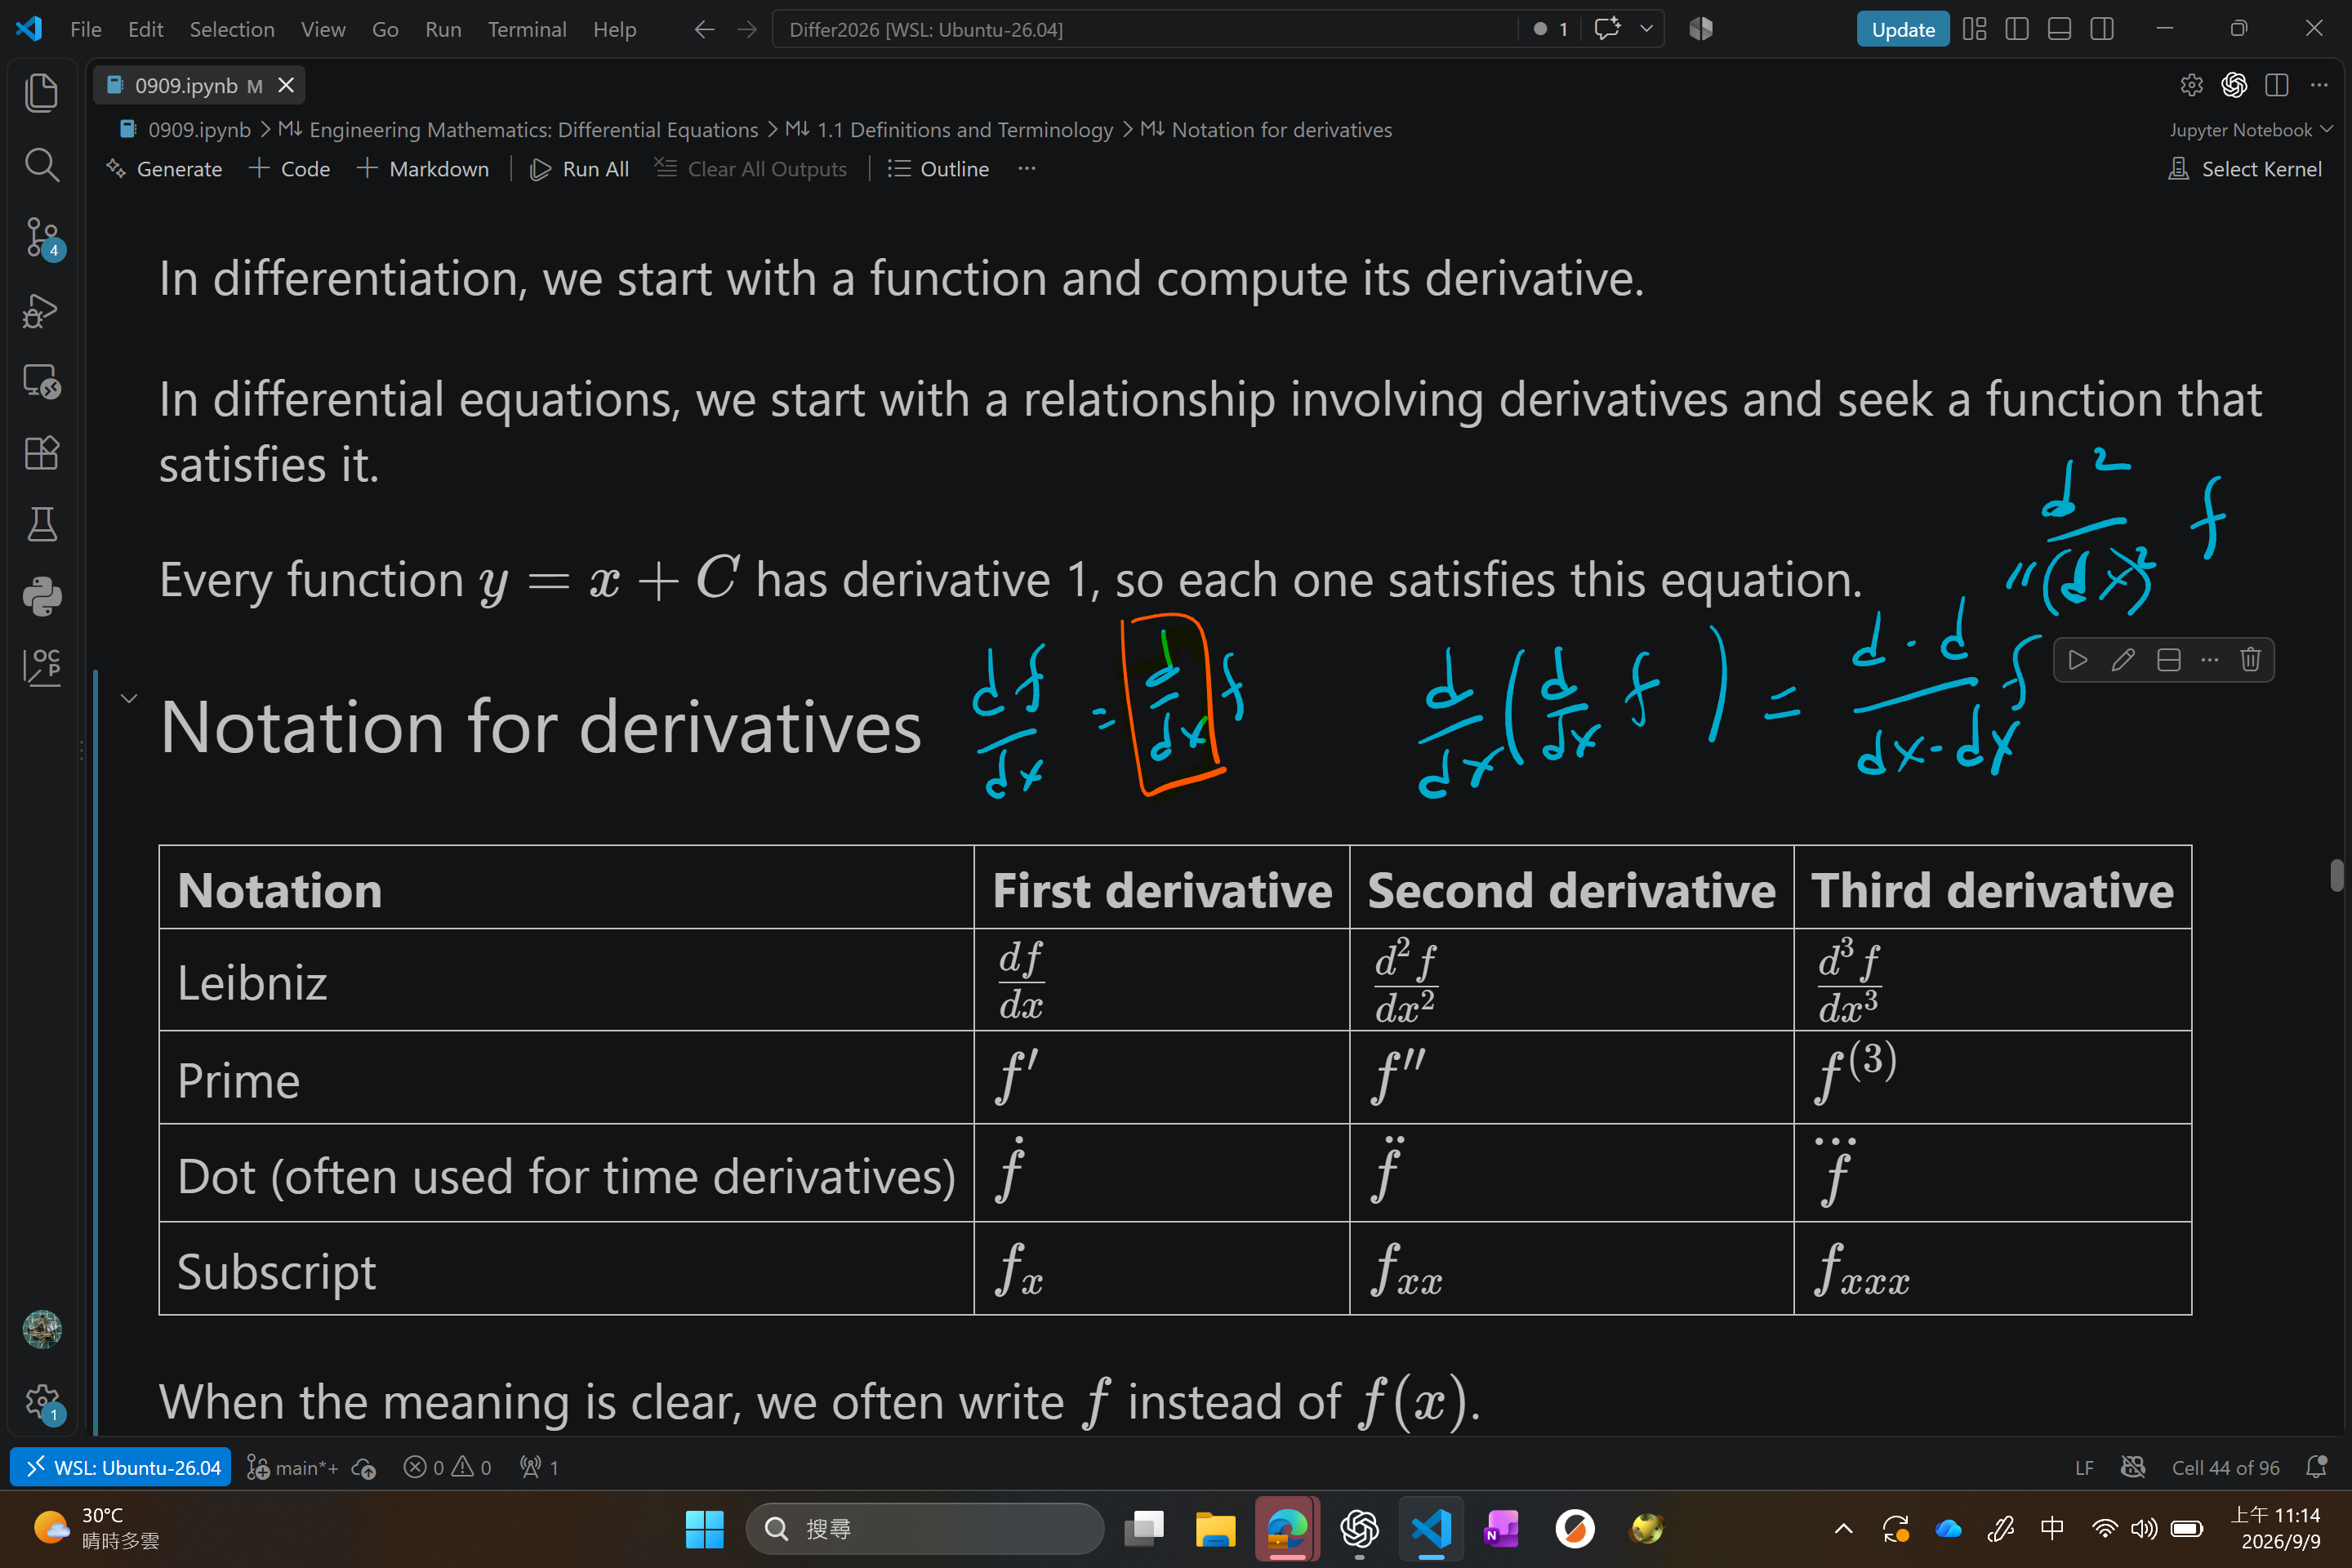

The symbol $f^{(4)}$ denotes the fourth derivative; $f^4$ denotes the fourth power.



### ODEs and PDEs



An **ordinary differential equation (ODE)** involves derivatives of unknown functions of one independent variable.

For example, for u(x)
$$ u^{(3)} + u'' + u' + \cos(6x)u = 0. $$

There may be several unknown functions,  
all depending on the same independent variable:
$$ \frac{dx}{dt} + \frac{dy}{dt} + \frac{dz}{dt} = 2xy + z. $$



A **partial differential equation (PDE)** involves partial derivatives of unknown functions of multiple independent variables.

For $u = u(x, y)$, an example is
$$ \frac{\partial^2u}{\partial x^2} + \frac{\partial^2u}{\partial y^2} = 0. $$



### Order

The **order** of a differential equation is the order of its highest derivative.
$$ y'' + 4y'-5y = e^x \qquad\text{second order} $$
$$ u^{(7)} + 2u^{(6)} + 2u^{(5)} + 4u^{(4)} = 0 \qquad\text{seventh order} $$

The equation $(y')^7 + y = 0$ is still first order.  
The power of a derivative does not determine the order.  
($(\bullet)^7$ is just a function; if that counts as seventh degree, what about $\cos(y)$?)



### Linear differential equations

An $n$ th-order linear ODE has the form

$$ a_n(x)y^{(n)} + a_{n - 1}(x)y^{(n - 1)} + \cdots + a_1(x)y' + a_0(x)y = g(x). $$



- $y$ and its derivatives appear only to the first power and are not multiplied together.
- The coefficients depend only on $x$, not on the unknown function $y$.
- $g(x)$ does not contain the unknown function.
- On an interval where we treat the equation as $n$th order, we normally require $a_n(x)\ne0$.

Coefficients such as $x^3$, $\sin x$, and $e^x$ are allowed.



Linearity concerns how the unknown function and its derivatives appear.



### Linear and nonlinear examples



| Equation | Order | Classification and reason |
|---|---|---|
| $(y - x)\,dx + 4x\,dy = 0$ | 1 | Linear: rewrite as $4xy' + y = x$ |
| $y''-2y' + y = 0$ | 2 | Linear |
| $xy^{(3)} + x^3y'-5y = e^x$ | 3 | Linear |
| $(y + 3)y'' + y' + 2y = x$ | 2 | Nonlinear: a coefficient depends on $y$ |
| $y'' + y' + y^2 = e^x$ | 2 | Nonlinear: contains $y^2$ |
| $y'' + y' + e^y = e^x$ | 2 | Nonlinear: contains $e^y$ |
| $(1 - y)y' + 2y = e^x$ | 1 | Nonlinear: contains $yy'$ |
| $y'' + \sin y = 0$ | 2 | Nonlinear: contains $\sin y$ |
| $y^{(4)} + y^2 = 0$ | 4 | Nonlinear: contains $y^2$ |



### What linearity gives us: superposition



Let $L[y] = a_n(x)y^{(n)} + \cdots + a_0(x)y$.  
For constants $b, c$,
$$ L[by_1 + cy_2] = bL[y_1] + cL[y_2]. $$

If $L[y_1] = g_1$ and $L[y_2] = g_2$, then
$$ L[by_1 + cy_2] = bg_1 + cg_2. $$
For a **homogeneous** equation $L[y] = 0$,  
every linear combination of two solutions is also a solution.



For a nonhomogeneous equation,  
keep track of the right-hand side:  
if both functions satisfy $L[y] = g$,  
their sum satisfies $L[y_1 + y_2] = 2g$,  
which need not be the original equation.

### Explicit and implicit solutions

An **explicit solution** gives the unknown function directly as $y = \phi(x)$.  
An **implicit solution** expresses a relationship $F(x, y) = 0$
that defines a solution on a suitable interval.  

Consider the equation
$$ \frac{d(y^2)}{dx} = -x \quad \Longleftrightarrow \quad 2yy' = -x. $$
Integration gives the implicit form
$$ \frac{x^2}{2} + y^2 = C. $$

Choosing the positive or negative branch gives explicit solutions:
$$ y = \sqrt{C - x^2/2}, \qquad y = -\sqrt{C - x^2/2}. $$

On open intervals where the radicand is positive,  
these branches are differentiable and satisfy the equation.  
Endpoints where $y = 0$ require separate checking and cannot simply be included.  
By the chain rule, $\frac{d(y^2)}{dx} = 2yy'$, not $(y')^2$.

### How do we verify a solution?



1. Specify the interval on which the function is defined.  
2. Compute the required derivatives.  
3. Substitute into the equation and check that it holds throughout the interval.  
4. Check any initial conditions separately.

Example: Does $y = e^x$ satisfy $y''-2y' + y = 0$?
$$ y' = e^x, \quad y'' = e^x, \quad e^x - 2e^x + e^x = 0. $$
Yes.

## 1.2 Initial Value Problems (IVPs)

### Using an initial condition to select a solution


The general solution of $y' = 1$ is
$$ y = x + C. $$

- If $y(0) = 2$, then $C = 2$, so $y = x + 2$.
- If $y(2) = 3.5$, then $C = 1.5$, so $y = x + 1.5$.

The initial point need not be zero.  
A differential equation together with initial conditions is called an **initial value problem**.

### Higher-order equations and initial conditions


An $n$th-order initial value problem typically specifies the following values at the same point:
$$ y(x_0), \ y'(x_0), \ \ldots, \ y^{(n - 1)}(x_0). $$

For example,
$$ y'' = 1\quad \Longrightarrow \quad y = \frac{x^2}{2} + Bx + C. $$
Given $y(0) = 1$ and $y'(0) = 5$,  
use $y' = x + B$ to obtain $B = 5$, and then $C = 1$.  
Thus,
$$ \boxed{y = \frac{x^2}{2} + 5x + 1}. $$

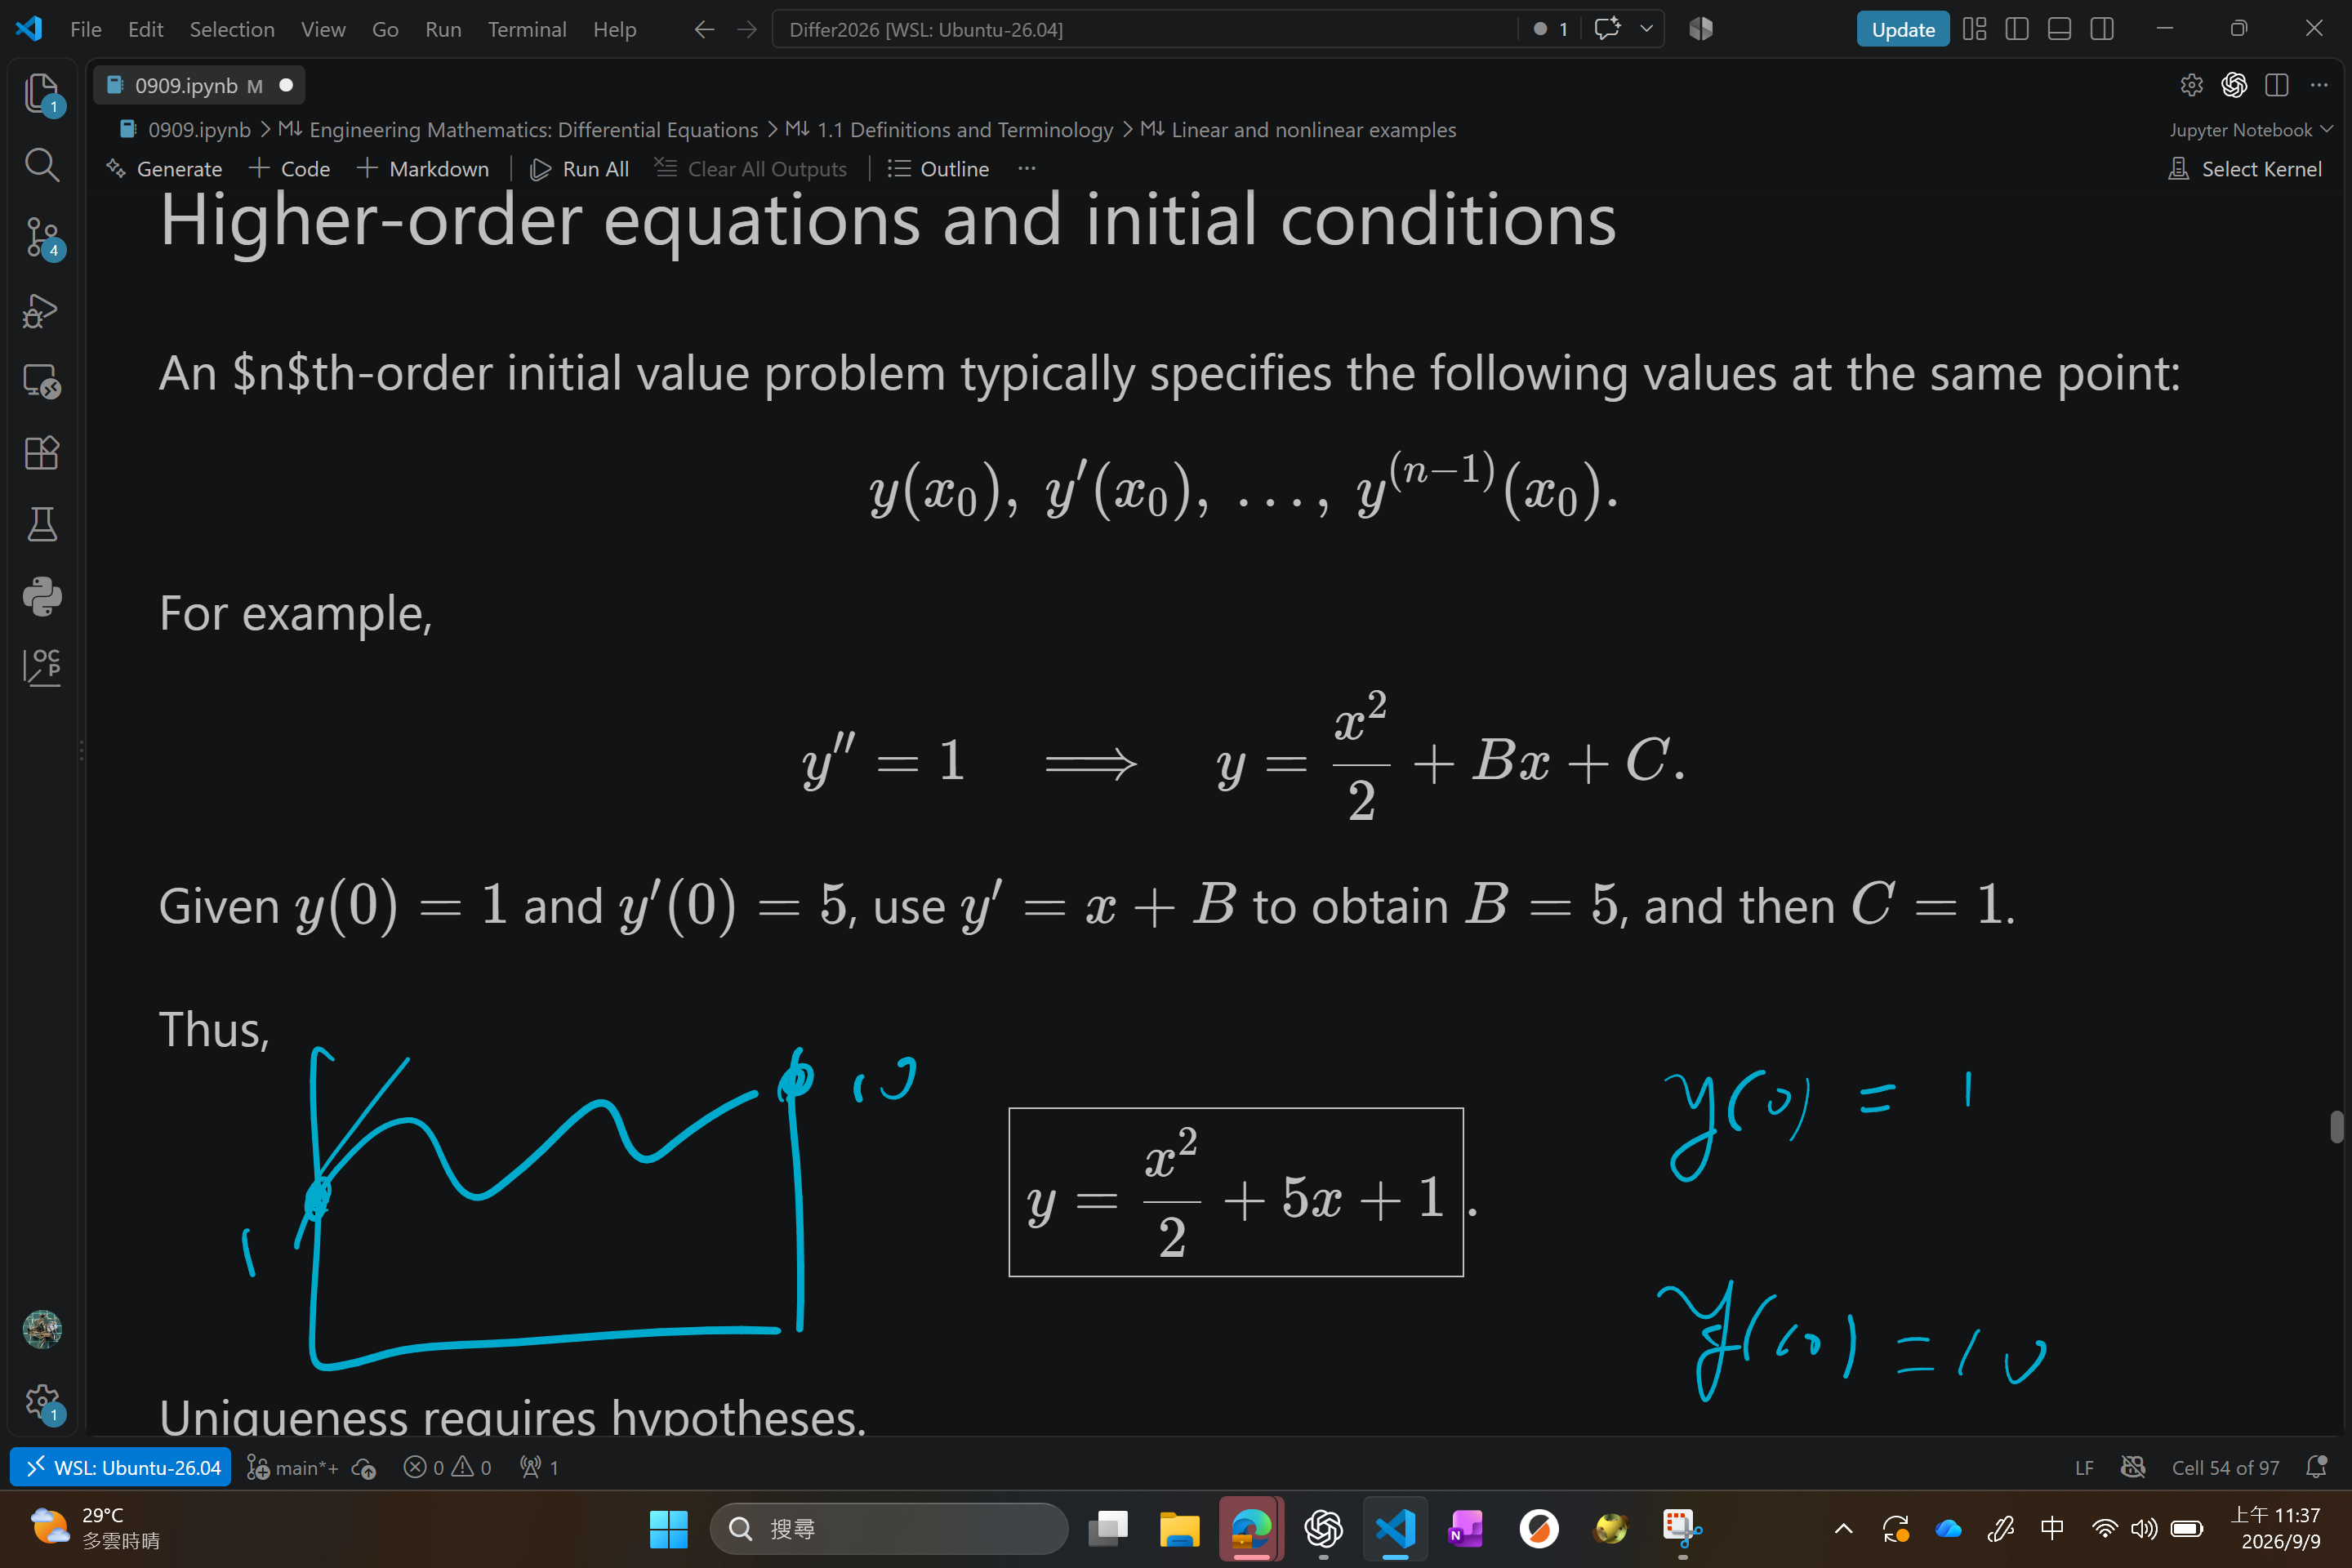

Uniqueness requires hypotheses.

For a linear equation with continuous coefficients and a continuous right-hand side on an interval,  
and with a nonzero leading coefficient throughout that interval,  
the standard $n$ initial conditions determine a unique solution.

Arbitrary differential equations do not automatically have unique solutions.
<https://mathworld.wolfram.com/UniversalDifferentialEquation.html?>

### Initial conditions and boundary conditions


Initial conditions specify data at the same point.  
Boundary conditions may specify data at different points.  
Again, $y'' = 1$ gives $y = x^2/2 + Bx + C$.

**Example 1: $y(1) = 2$ and $y(2) = 3$.**  
$$ B + C = \frac32, \quad 2B + C = 1\quad \Longrightarrow \quad B = -\frac12, \ C = 2. $$
$$ y = \frac{x^2}{2} - \frac{x}{2} + 2. $$

**Example 2: $y(0) = 1$ and $y'(3) = 2$.**
$$ C = 1, \quad 3 + B = 2\quad \Longrightarrow \quad y = \frac{x^2}{2} - x + 1. $$
Having enough boundary conditions does not, by itself,
guarantee existence or uniqueness for a general boundary value problem.

### Practice: try these first



1. Classify $y'' + (y')^2 = x$: ODE or PDE? What order? Linear or nonlinear?  
2. Classify $u_t = u_{xx}$ in the same way.  
3. Solve $y' = 1$ with $y(2) = 3.5$.  
4. Solve $y'' = 1$ with $y(0) = 1$ and $y'(0) = 5$.  
5. Differentiate $x^2/2 + y^2 = C$ to verify the corresponding differential equation.

### Answers



1. A second-order nonlinear ODE.  
2. A second-order linear PDE.
3. $y = x + 1.5$.
4. $y = x^2/2 + 5x + 1$.
5. $x + 2yy' = 0$, or $2yy' = -x$.



## Homework Due Sunday

Find a polynomial solution $f = f(x)$ for each differential equation.  
In part $n$, try a polynomial of degree $n$ and determine its coefficients by substitution.

Compare coefficients from the highest power of $x$ down to the constant term.  
Verify your answer in the original equation.

You do not need to find the general non-polynomial solution.


Find a polynomial solution of degree 1:
$$ f - f' = x. $$

Find a polynomial solution of degree 2:
$$ 13f'' + 12f' + 144f = -864x^2. $$

Find a polynomial solution of degree 3:
$$ 3f^{(3)} + 95f'' + 300f' + 750f = 3750x^3. $$

Find a polynomial solution of degree 4:
$$ 6307f^{(4)} - 7096f^{(3)} + 7872f'' - 7680f' + 12288f = 24576x^4. $$

## Homework Due Wednesday


A swimming pool with a daily contamination cycle

Fresh water enters a well-mixed swimming pool while mixed water drains out at the same rate.  
The pool volume stays constant.

More people use the pool in the morning, so contamination varies over the day.  
Model the contaminant input rate as proportional to $1 + \sin t$.

Choose time units so that one day corresponds to $2\pi$, with $t = 0$ at midnight.  
Thus $t = \pi/2$ corresponds to 6 a.m., when the contaminant input is highest.

After choosing concentration units and a water-replacement rate, the model is
$$ c'(t) = -c(t) + 1 + \sin t, \qquad c(0) = 0. $$

### 1. Interpret the model



Explain what each term represents.  
Why is $1 + \sin t$ a possible input rate,  
while $\sin t$ alone would not be?

### 2. Find the solution



Look for a solution of the form
$$ c(t) = A + B\sin t + C\cos t + De^{-t}. $$
Differentiate and substitute into the differential equation.  
Compare the constant, sine, and cosine terms to find $A$, $B$, and $C$.

Use $c(0) = 0$ to determine $D$.  
Verify that your final expression satisfies both the equation and the initial condition.


### 3. Describe the long-term behavior



Which term in your solution tends to zero as $t \to \infty$?  
Let $c_{\mathrm{per}}(t)$ be the expression that remains after removing that term.

Does $c(t)$ approach a constant or a repeating daily cycle?  
Find the maximum and minimum values of $c_{\mathrm{per}}(t)$.


### 4. When is the pool most contaminated?



Find the time of day when $c_{\mathrm{per}}(t)$ reaches its maximum.  
Compare it with the 6 a.m. peak in the contaminant input rate.

Express the delay in hours.  
Explain why the concentration does not peak at the same time as the input rate.

Use the long-term periodic expression for this part, rather than the initial-day solution.
